# **Modelo MLP**

Para adaptar la serie de tiempo al formato requerido por el modelo MLP, se implementó una transformación mediante la técnica de ventana deslizante (sliding window). Esta técnica consiste en recorrer la serie de forma secuencial, construyendo en cada paso un vector de entrada compuesto por las observaciones pasadas y un valor objetivo a predecir. Se definió un tamaño de ventana de 24 horas (window_size = 24), decisión respaldada por la naturaleza de los datos: dado que el consumo energético presenta una marcada estacionalidad diaria, incorporar un ciclo completo de 24 horas como contexto permite al modelo capturar los patrones de demanda más relevantes, tales como los picos matutinos, los valles nocturnos y las diferencias entre horas laborales y no laborales.

En cada iteración, el vector de entrada se construyó concatenando dos componentes. El primero corresponde a los 24 rezagos del consumo energético escalado (Value_scaled), que representan el historial de consumo de las 24 horas previas al momento a predecir. El segundo componente está conformado por cuatro variables exógenas asociadas al instante de predicción: la hora del día, el día de la semana, el mes del año y el tipo de clima del país (codificado como variable dummy, donde 0 corresponde a clima frío y 1 a clima cálido). Estas variables se toman del momento futuro a predecir — no del pasado — dado que su valor es conocido de antemano y proporciona al modelo información contextual sobre las condiciones en las que ocurrirá el consumo. El resultado es una matriz de entrada X, donde cada fila representa una ventana de observación y cada columna uno de los 28 inputs del modelo.

In [ ]:
window_size = 24
X, y, timestamps = [], [], []

vals  = df['Value_scaled'].values
hora  = df['hora'].values
dia   = df['dia_semana'].values
mes   = df['mes'].values
clima = df['clima_num'].values
idx   = df.index

for i in range(len(df) - window_size):
    rezagos = vals[i : i + window_size]
    exog    = [hora[i + window_size],
               dia[i + window_size],
               mes[i + window_size],
               clima[i + window_size]]
    X.append(np.concatenate([rezagos, exog]))
    y.append(vals[i + window_size])
    timestamps.append(idx[i + window_size]) #indice temporal de la observación que se predice

X          = np.array(X)
y          = np.array(y)
timestamps = pd.DatetimeIndex(timestamps) #convierte indices en fecha de pandas para hacer los cortes de los conjuntos de datos

# Partición con cortes temporales exactos
val_start  = pd.Timestamp('2025-06-01')
test_start = pd.Timestamp('2025-12-01')

train_mask = timestamps < val_start
val_mask   = (timestamps >= val_start) & (timestamps < test_start)
test_mask  = timestamps >= test_start

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"X shape: {X.shape} → {window_size} rezagos + 4 exógenas = {X.shape[1]} inputs")
print(f"Train: {X_train.shape[0]} obs  ({timestamps[train_mask][0].date()} → {timestamps[train_mask][-1].date()})")
print(f"Val:   {X_val.shape[0]} obs  ({timestamps[val_mask][0].date()} → {timestamps[val_mask][-1].date()})")
print(f"Test:  {X_test.shape[0]} obs  ({timestamps[test_mask][0].date()} → {timestamps[test_mask][-1].date()})")

X shape: (175404, 28) → 24 rezagos + 4 exógenas = 28 inputs
Train: 124051 obs  (2024-01-01 → 2025-05-31)
Val:   43913 obs  (2025-06-01 → 2025-11-30)
Test:  7440 obs  (2025-12-01 → 2025-12-31)


## **Definición de arquitecturas y construcción del modelo**

Con el objetivo de identificar la configuración óptima de la red neuronal, se implementó una búsqueda exhaustiva sobre un conjunto predefinido de arquitecturas. Se consideraron redes con un máximo de tres capas ocultas y tres opciones de neuronas por capa: 32, 64 y 128. Dado que cada neurona constituye una unidad de detección de patrones, el número de neuronas por capa determina la capacidad del modelo para representar relaciones en los datos — un mayor número permite capturar patrones más complejos, pero incrementa el costo computacional.

Las arquitecturas se generaron mediante la función itertools.product, que produce todas las combinaciones posibles de neuronas repitiendo las opciones disponibles para cada número de capas. Esto da lugar a 3 arquitecturas de una capa, 9 de dos capas y 27 de tres capas, para un total de 39 arquitecturas distintas. Cada arquitectura queda representada como una tupla — por ejemplo, (128, 64, 32) indica una red con tres capas ocultas de 128, 64 y 32 neuronas respectivamente.

Complementariamente, se definió la función dropout_configs, que genera todas las combinaciones posibles de aplicar o no la técnica de dropout en cada capa oculta. El dropout es una técnica de regularización que durante el entrenamiento desactiva aleatoriamente un porcentaje de neuronas — en este caso el 50% — con el fin de reducir la dependencia entre unidades y prevenir el sobreajuste. La función utiliza la representación binaria de números enteros para codificar las combinaciones: cada bit indica si una capa tiene dropout activado (1) o no (0). Para una arquitectura de tres capas se generan 2³ = 8 combinaciones, lo que junto con las 39 arquitecturas da un espacio de búsqueda de 258 configuraciones en total.

La construcción de cada modelo se realizó mediante la función construir_modelo, que recibe como argumentos la arquitectura, la máscara de dropout y la dimensión de entrada. El modelo se construye de forma secuencial: primero se define la capa de entrada con 28 nodos — correspondientes a los 24 rezagos y las 4 variables exógenas — seguida de las capas ocultas con función de activación ReLU, con dropout insertado en las capas que así lo indique la máscara, y finalmente una capa de salida con una sola neurona sin función de activación, apropiada para tareas de regresión. El modelo se compila con el optimizador Adam, la función de pérdida MSE y el RMSE como métrica de monitoreo durante el entrenamiento.

In [ ]:
neuronas      = [32, 64, 128] #cada neurona es una unidad de deteccion de patrones
max_capas     = 3
arquitecturas = []
for n in range(1, max_capas + 1):
    for comb in itertools.product(neuronas, repeat=n): #genera todas las combinaciones posibles de un conjunto de opciones repitiendo n veces
        arquitecturas.append(comb)

def dropout_configs(n_capas):
    for mask in range(2**n_capas):
        yield tuple(bool((mask >> i) & 1) for i in range(n_capas))

def construir_modelo(arquitectura, dropout_mask, input_dim):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    for idx, units in enumerate(arquitectura): #Para las capas ocultas
        model.add(tf.keras.layers.Dense(units, activation="relu"))
        if dropout_mask[idx]:
            model.add(tf.keras.layers.Dropout(0.5))
    model.add(tf.keras.layers.Dense(1))
    model.compile(optimizer="adam", loss="mse",
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

input_dim = X_train.shape[1]  # 28 = 24 rezagos + 4 exógenas
print(f"Input dim: {input_dim} | Arquitecturas a probar: {len(arquitecturas)}")

Input dim: 28 | Arquitecturas a probar: 39


### **Función de test BDS**

Con el fin de evaluar la calidad del ajuste de cada modelo estimado, se implementó la función calcular_bds_completo, que aplica el test BDS (Brock, Dechert y Scheinkman, 1996) sobre los residuos de predicción. Este test examina si los residuos de un modelo son independientes e idénticamente distribuidos (i.i.d.), lo que constituye una condición necesaria para considerar que el modelo capturó adecuadamente la estructura de la serie. A diferencia del test de Ljung-Box, que detecta únicamente dependencias lineales, el test BDS es capaz de identificar dependencias no lineales y estructuras caóticas en los residuos, lo que lo convierte en un diagnóstico más completo para modelos de aprendizaje automático.

Las hipótesis del test son las siguientes:

- H₀: los residuos son independientes e idénticamente distribuidos (i.i.d.)
- H₁: los residuos presentan alguna forma de dependencia estructural

Un p-valor superior a 0.05 indica que no se rechaza H₀, lo que sugiere que los residuos se comportan como ruido blanco y que el modelo capturó la estructura relevante de la serie. Por el contrario, un p-valor inferior a 0.05 evidencia la presencia de patrones no capturados, lo que podría justificar el uso de modelos con mayor capacidad para representar dependencias temporales.
Antes de aplicar el test, los residuos se estandarizaron para tener media cero y desviación estándar unitaria, con el fin de garantizar que los parámetros del test sean comparables entre modelos. Se incluyó una protección numérica de 1e-8 en el denominador para evitar divisiones por cero. Adicionalmente, se establecieron dos condiciones de validación previas: que los residuos contengan al menos 100 observaciones — umbral mínimo para la confiabilidad estadística del test — y que presenten variación real, descartando casos en los que todos los residuos sean prácticamente idénticos.

El test se aplicó para nueve combinaciones de parámetros, resultantes de cruzar tres valores de epsilon (0.5, 1.0 y 1.5, expresados como múltiplos de la desviación estándar de los residuos) con tres dimensiones de embedding (m = 2, 3 y 4). El parámetro epsilon define la distancia de vecindad utilizada para comparar pares de puntos, mientras que la dimensión m determina la longitud de las subsecuencias analizadas — valores mayores de m permiten detectar dependencias en estructuras temporales más largas. El uso de múltiples combinaciones de parámetros fortalece la robustez del diagnóstico: si el test rechaza H₀ de forma consistente en la mayoría de combinaciones, la evidencia de estructura residual es sólida. Los resultados se almacenaron en un diccionario con claves descriptivas del tipo m{m}_eps{eps_factor}, y en caso de fallo numérico en alguna combinación, el valor correspondiente se registró como NaN para preservar la continuidad del proceso.


In [ ]:
def calcular_bds_completo(residuos):
    resultados_bds = {}
    #estandariza residuos para tener media 0 y var des.est 1
    residuos_std = (residuos - np.mean(residuos)) / (np.std(residuos) + 1e-8)
#si hay menos de 100 puntos y la variacion de los residuos es casi nula retorna none
    if len(residuos_std) < 100 or np.std(residuos_std) < 1e-6:
        return None

    epsilons   = [0.5, 1.0, 1.5]
    dimensiones = [2, 3, 4]

    for eps_factor in epsilons:
        eps = eps_factor * np.std(residuos_std)
        for m in dimensiones:
            try:
                stat, pval = bds(residuos_std, max_dim=m, epsilon=eps)
                resultados_bds[f"m{m}_eps{eps_factor}"] = float(pval[-1])
            except:
                resultados_bds[f"m{m}_eps{eps_factor}"] = np.nan

    return resultados_bds

## **Entrenamiento, evaluación y selección de modelos**

El proceso de entrenamiento se estructuró mediante una búsqueda exhaustiva sobre el espacio de configuraciones definido previamente, combinando las 39 arquitecturas con sus respectivas configuraciones de dropout para un total de 258 modelos entrenados y evaluados de forma sistemática.

Con el fin de controlar el sobreajuste y optimizar el tiempo computacional, se implementó la técnica de *early stopping* mediante el callback `EarlyStopping` de Keras. Este mecanismo monitorea el valor de la función de pérdida sobre el conjunto de validación (`val_loss`) al final de cada época y detiene el entrenamiento cuando dicha métrica no presenta mejora durante 5 épocas consecutivas — valor definido por el parámetro `patience`. Al momento de la detención, el parámetro `restore_best_weights=True` garantiza que el modelo conserve los pesos correspondientes a la época de mejor desempeño en validación, y no los de la última época ejecutada. Se estableció un máximo de 50 épocas como límite superior del entrenamiento.

En cada iteración del loop, la memoria de la sesión de Keras se liberó mediante `clear_session()` antes de construir el nuevo modelo, evitando la acumulación de grafos computacionales en memoria que puede derivar en errores de hardware durante entrenamientos prolongados. Cada modelo se entrenó con un tamaño de lote (*batch size*) de 32 observaciones, lo que implica que los pesos se actualizan aproximadamente 3,877 veces por época — resultado de dividir las 124,051 observaciones de entrenamiento entre el tamaño del lote.

El conjunto de validación cumple un rol exclusivamente de monitoreo: no aporta información al proceso de ajuste de pesos, pero permite detectar señales de sobreajuste época a época e informa al mecanismo de *early stopping* sobre el momento óptimo de detención. Una vez finalizado el entrenamiento de cada modelo, se generaron predicciones sobre el conjunto de prueba y se calcularon tres métricas de evaluación. El RMSE (*Root Mean Squared Error*) cuantifica el error en las mismas unidades que la variable de consumo escalada, penalizando con mayor peso los errores de mayor magnitud. El MAPE (*Mean Absolute Percentage Error*) expresa el error en términos porcentuales, facilitando la interpretación y comparación entre modelos independientemente de la escala. El *gap* entre el error de entrenamiento final y el mejor error de validación actúa como indicador de sobreajuste: valores reducidos sugieren que el modelo generaliza bien a datos no vistos, mientras que valores elevados evidencian memorización del conjunto de entrenamiento.

Adicionalmente, se calcularon los residuos de predicción como la diferencia entre los valores reales y los predichos, sobre los cuales se aplicaron dos pruebas de diagnóstico complementarias. El test de Ljung-Box, con un rezago de 10 períodos, evalúa la presencia de autocorrelación lineal en los residuos. El test BDS, descrito en la sección anterior, examina la existencia de dependencias no lineales. Ambos tests se aplican bajo la hipótesis nula de que los residuos son ruido blanco: p-valores superiores a 0.05 indican un ajuste adecuado del modelo, mientras que p-valores inferiores señalan la presencia de estructura residual no capturada. 

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience= 5,
    restore_best_weights=True
)

resultados = []
epochs = 20

for arch in arquitecturas:
    for dmask in dropout_configs(len(arch)):
        tf.keras.backend.clear_session()
        model = construir_modelo(arch, dmask, input_dim)
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val), #no da info al entreno, monitoria sobre ajustes e informa al early stopping
            epochs=epochs, batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )
        train_rmse = history.history["root_mean_squared_error"]
        val_rmse   = history.history["val_root_mean_squared_error"]
        best_val   = np.min(val_rmse)
        gap        = abs(train_rmse[-1] - best_val) # indicador de sobreajuste: mide la diferencia entre el error de entrenamiento final y el mejor error de validación

        y_pred_test = model.predict(X_test, verbose=0).flatten()
        test_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_test))
        mape        = mean_absolute_percentage_error(y_test + 1e-8, y_pred_test)
        residuos    = y_test - y_pred_test
        bds_dict  = calcular_bds_completo(residuos)
        try:
            lb = acorr_ljungbox(residuos, lags=[10], return_df=True)
            lb_pvalue = lb["lb_pvalue"].values[0]
        except:
            lb_pvalue = np.nan

        resultados.append({
            "arquitectura": arch, "dropout_mask": dmask,
            "best_val_rmse": best_val, "test_rmse": test_rmse,
            "mape": mape, "lb_pvalue": lb_pvalue, "bds": bds_dict,"gap": gap,
            "train_curve": train_rmse, "val_curve": val_rmse,
            "y_pred_test": y_pred_test
        })

El modelo seleccionado, correspondiente a una arquitectura simple de una sola capa oculta con 32 neuronas y sin aplicación de dropout, presenta un desempeño mixto. En términos de precisión, el RMSE en el conjunto de prueba (0.2163) es consistente con el error de validación (0.1910), y el bajo valor del gap (0.007) sugiere una adecuada capacidad de generalización, sin evidencia significativa de sobreajuste. No obstante, el MAPE alcanza un valor elevado (234.75%), lo que indica dificultades del modelo para capturar correctamente la magnitud relativa del consumo, especialmente en valores bajos. Desde el punto de vista de diagnóstico, el test de Ljung-Box (p-valor = 0.0166) rechaza la hipótesis de ausencia de autocorrelación, evidenciando que persiste dependencia lineal en los residuos. Asimismo, los resultados del test BDS, con p-valores cercanos a cero en múltiples dimensiones y valores de epsilon, confirman la presencia de dependencias no lineales no capturadas por el modelo. En conjunto, estos resultados indican que, si bien el modelo logra una aproximación razonable del nivel general de la serie, no captura completamente la estructura temporal subyacente, especialmente en términos de dinámicas complejas y patrones no lineales.

In [12]:
df_res = pd.DataFrame([{
    'arquitectura':  r['arquitectura'],
    'dropout_mask':  r['dropout_mask'],
    'val_rmse':      r['best_val_rmse'],
    'test_rmse':     r['test_rmse'],
    'mape':          r['mape'],
    'lb_pvalue':     r['lb_pvalue'],
    'gap':           r['gap'],
    'bds_m2_eps0.5': r['bds']['m2_eps0.5'] if r['bds'] else np.nan,
    'bds_m2_eps1.0': r['bds']['m2_eps1.0'] if r['bds'] else np.nan,
    'bds_m2_eps1.5': r['bds']['m2_eps1.5'] if r['bds'] else np.nan,
    'bds_m3_eps0.5': r['bds']['m3_eps0.5'] if r['bds'] else np.nan,
    'bds_m3_eps1.0': r['bds']['m3_eps1.0'] if r['bds'] else np.nan,
    'bds_m3_eps1.5': r['bds']['m3_eps1.5'] if r['bds'] else np.nan,
    'bds_m4_eps0.5': r['bds']['m4_eps0.5'] if r['bds'] else np.nan,
    'bds_m4_eps1.0': r['bds']['m4_eps1.0'] if r['bds'] else np.nan,
    'bds_m4_eps1.5': r['bds']['m4_eps1.5'] if r['bds'] else np.nan,
} for r in resultados])

# Top 5 mejores por test RMSE
print(df_res.sort_values('test_rmse').head(5).to_string(index=False))

arquitectura dropout_mask  val_rmse  test_rmse     mape  lb_pvalue     gap  bds_m2_eps0.5  bds_m2_eps1.0  bds_m2_eps1.5  bds_m3_eps0.5  bds_m3_eps1.0  bds_m3_eps1.5  bds_m4_eps0.5  bds_m4_eps1.0  bds_m4_eps1.5
       (32,)     (False,)  0.191048   0.216322 2.347543   0.016586 0.00707            NaN            NaN            NaN   8.713662e-13       0.000001   1.869940e-26   4.241255e-12   1.034556e-08   3.883996e-33


La figura presenta, en el panel superior, la comparación entre el consumo energético real y el predicho por el modelo MLP (32,) para las primeras 500 horas del conjunto de prueba. Se observa que el modelo logra capturar adecuadamente la tendencia general y la dinámica promedio de la serie; sin embargo, presenta una clara dificultad para reproducir la alta volatilidad del consumo. En particular, las predicciones muestran un comportamiento suavizado, subestimando de manera sistemática los picos máximos y sobreestimando los valores más bajos. Esto sugiere que el modelo tiende a aproximarse al valor medio de la serie, sin lograr capturar completamente los eventos extremos.

En el panel inferior se presentan las curvas de aprendizaje del modelo. El error de entrenamiento (Train RMSE) muestra una caída pronunciada en las primeras épocas y luego se estabiliza, mientras que el error de validación (Val RMSE) presenta ligeras fluctuaciones pero converge a valores cercanos al entrenamiento. La cercanía entre ambas curvas y el bajo *gap* indican que no hay evidencia significativa de sobreajuste, y que el modelo generaliza de manera relativamente estable. La línea vertical punteada señala la época óptima seleccionada por el mecanismo de *early stopping*, a partir de la cual no se observan mejoras sustanciales en el desempeño. En conjunto, los resultados sugieren que el modelo converge rápidamente y de forma estable, pero con una capacidad limitada para capturar la complejidad y variabilidad extrema de la serie.

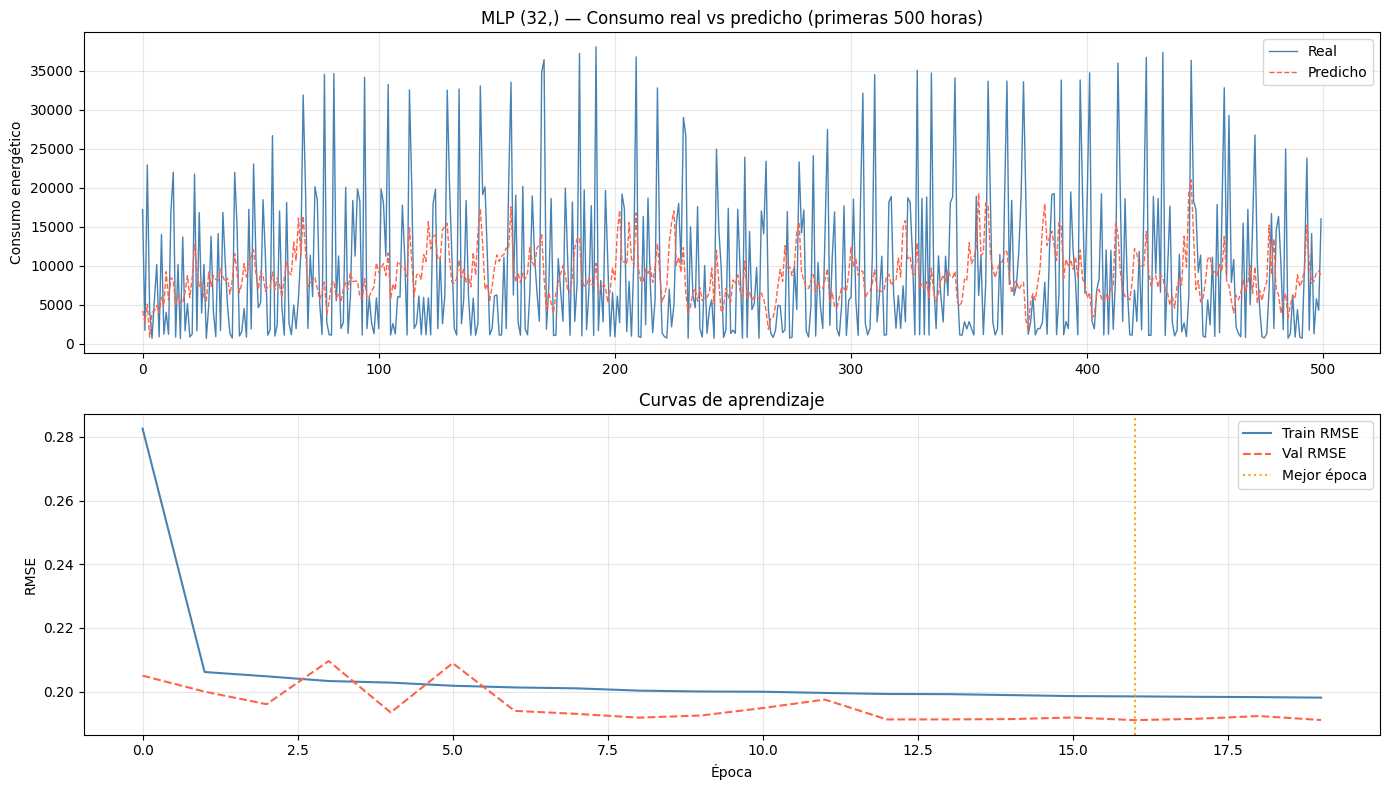


Arquitectura: (32,)
Dropout mask: (False,)
Test RMSE:    0.2163
MAPE:         234.75%
LB p-valor:   1.66e-02


In [13]:
# Extraer mejor modelo
mejor_idx  = df_res['test_rmse'].idxmin()
mejor      = resultados[mejor_idx]

# Invertir escala para tener valores reales de consumo
mejor_pred  = scaler.inverse_transform(mejor['y_pred_test'].reshape(-1, 1)).flatten()
real_values = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1 — primeras 500 horas
axes[0].plot(real_values[:500], label='Real', linewidth=1, color='steelblue')
axes[0].plot(mejor_pred[:500], label='Predicho', linewidth=1, linestyle='--', color='tomato')
axes[0].set_title(f"MLP {mejor['arquitectura']} — Consumo real vs predicho (primeras 500 horas)")
axes[0].set_ylabel('Consumo energético')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2 — curvas de aprendizaje
axes[1].plot(mejor['train_curve'], label='Train RMSE', color='steelblue')
axes[1].plot(mejor['val_curve'],   label='Val RMSE',   color='tomato', linestyle='--')
axes[1].axvline(x=np.argmin(mejor['val_curve']), color='orange', linestyle=':', label='Mejor época')
axes[1].set_title('Curvas de aprendizaje')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nArquitectura: {mejor['arquitectura']}")
print(f"Dropout mask: {mejor['dropout_mask']}")
print(f"Test RMSE:    {mejor['test_rmse']:.4f}")
print(f"MAPE:         {mejor['mape']*100:.2f}%")
print(f"LB p-valor:   {mejor['lb_pvalue']:.2e}")

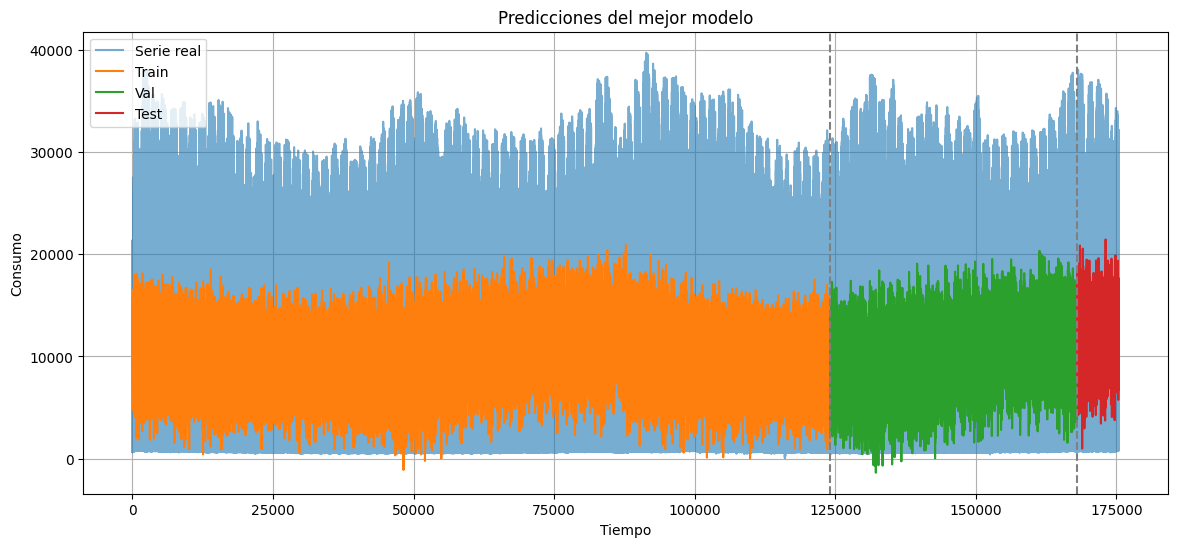

In [26]:
graficar_predicciones_full(
    serie,
    y_train, y_val, y_test,
    y_pred_train,
    y_pred_val,
    y_pred_test,
    window_size,
    scaler
)

Se consideró la posibilidad de entrenar los modelos bajo configuraciones más exigentes en términos de duración del entrenamiento, incrementando tanto el número máximo de épocas como el parámetro de patience del mecanismo de early stopping. En particular, se planteó la implementación de esquemas con hasta 200 épocas y valores de patience entre 50 y 60, lo cual podría permitir al modelo explorar de manera más amplia el espacio de soluciones y potencialmente alcanzar un mejor ajuste, especialmente en presencia de dinámicas complejas en la serie. No obstante, debido a limitaciones de capacidad computacional, no fue posible ejecutar este tipo de configuraciones más demandantes dentro del tiempo disponible. En consecuencia, no se descarta que un mayor esfuerzo de entrenamiento, bajo condiciones de hardware más robustas, pueda traducirse en mejoras adicionales en el desempeño predictivo del modelo.